In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path(".")

In [2]:
list(DATA_DIR.glob("*.csv"))

[PosixPath('FailedSSHLoginCount-2026_08_19_12_40_00-2026_08_21_02_15_00-UTC.csv'),
 PosixPath('RDS-FreeStorageSpace-2026_08_19_13_48_00-2026_08_26_13_46_00-UTC.csv'),
 PosixPath('RDS-DatabaseConnections-2026_08_19_12_52_00-2026_08_26_12_50_00-UTC.csv'),
 PosixPath('CloudWatch-CPUUtilization-2026_08_19_12_45_00-2026_08_26_11_45_00-UTC.csv'),
 PosixPath('RDS-CPUUtilization-2026_08_19_12_39_00-2026_08_26_12_37_00-UTC.csv')]

In [3]:
list(DATA_DIR.glob("*.csv"))

[PosixPath('FailedSSHLoginCount-2026_08_19_12_40_00-2026_08_21_02_15_00-UTC.csv'),
 PosixPath('RDS-FreeStorageSpace-2026_08_19_13_48_00-2026_08_26_13_46_00-UTC.csv'),
 PosixPath('RDS-DatabaseConnections-2026_08_19_12_52_00-2026_08_26_12_50_00-UTC.csv'),
 PosixPath('CloudWatch-CPUUtilization-2026_08_19_12_45_00-2026_08_26_11_45_00-UTC.csv'),
 PosixPath('RDS-CPUUtilization-2026_08_19_12_39_00-2026_08_26_12_37_00-UTC.csv')]

In [4]:
ec2_file = list(DATA_DIR.glob("CloudWatch-CPU*.csv"))[0]
ec2_cpu = pd.read_csv(ec2_file)
ec2_cpu.head()

,Id,m1
0,StatusCode,Complete
1,Messages,NaN
2,Full label,eu-west-2:AWS/EC2 AutoScalingGroupName:medicor...
3,Label,CPUUtilization
4,2026/08/19 12:45:00,0.00337120539089125


In [5]:
ec2_clean = ec2_cpu.iloc[4:].copy()
ec2_clean.columns = ["timestamp", "cpu_percent"]
ec2_clean.head()

,timestamp,cpu_percent
4,2026/08/19 12:45:00,0.00337120539089125
5,2026/08/19 12:50:00,2.6974732216975346
6,2026/08/19 12:55:00,0.22915664979090952
7,2026/08/19 13:00:00,0.1941395482429557
8,2026/08/19 13:05:00,0.6460404376265096


In [6]:
ec2_clean["timestamp"] = pd.to_datetime(ec2_clean["timestamp"])
ec2_clean["cpu_percent"] = pd.to_numeric(ec2_clean["cpu_percent"])
ec2_clean.dtypes

timestamp      datetime64[us]
cpu_percent           float64
dtype: object

In [7]:
ec2_clean["cpu_percent"].describe()

count    507.000000
mean       0.163574
std        0.193635
min        0.000564
25%        0.111666
50%        0.134992
75%        0.150871
max        2.857824
Name: cpu_percent, dtype: float64

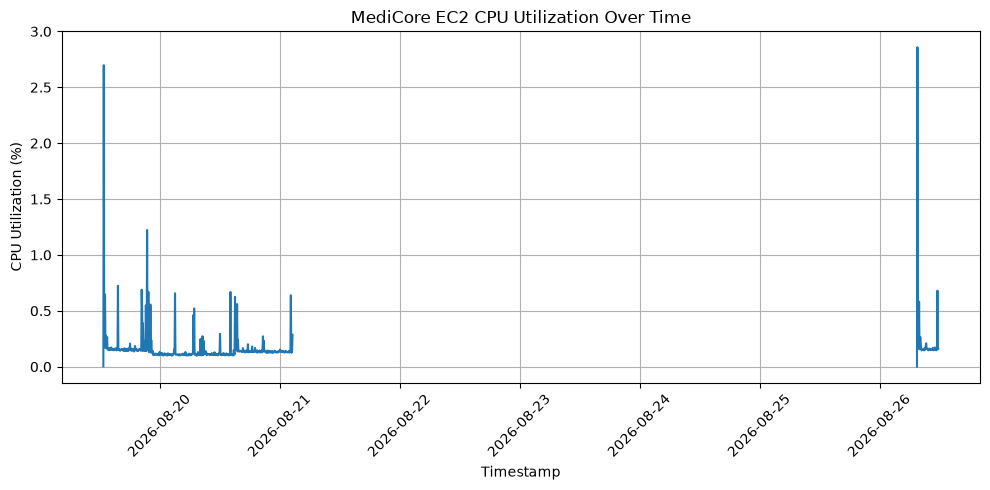

In [28]:
plt.figure(figsize=(10,5))
plt.plot(ec2_clean["timestamp"], ec2_clean["cpu_percent"])
plt.title("MediCore EC2 CPU Utilization Over Time")
plt.xlabel("Timestamp")
plt.ylabel("CPU Utilization (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("EC2_CPU_Utilization.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
print(ec2_clean.columns.tolist())

['timestamp', 'cpu_percent']


In [11]:
from pathlib import Path

ssh_file = list(Path(".").glob("FailedSSHLoginCount*.csv"))[0]
ssh_raw = pd.read_csv(ssh_file)

ssh_raw.head(10)

,Id,m1
0,StatusCode,Complete
1,Messages,NaN
2,Full label,eu-west-2:MediCore/Security FailedSSHLoginCoun...
3,Label,FailedSSHLoginCount
4,2026/08/19 12:40:00,0
5,2026/08/19 12:45:00,NaN
6,2026/08/19 12:50:00,NaN
7,2026/08/19 12:55:00,NaN
8,2026/08/19 13:00:00,NaN
9,2026/08/19 13:05:00,NaN


In [12]:
ssh_clean = ssh_raw.iloc[4:].copy()

ssh_clean.columns = ["timestamp", "failed_logins"]

ssh_clean["timestamp"] = pd.to_datetime(ssh_clean["timestamp"])
ssh_clean["failed_logins"] = pd.to_numeric(ssh_clean["failed_logins"], errors="coerce").fillna(0)

print(ssh_clean.head())
print()
print(ssh_clean["failed_logins"].describe())
print()
print("Maximum failed logins:", ssh_clean["failed_logins"].max())
print("Non-zero datapoints:", (ssh_clean["failed_logins"] > 0).sum())


            timestamp  failed_logins
4 2026-08-19 12:40:00            0.0
5 2026-08-19 12:45:00            0.0
6 2026-08-19 12:50:00            0.0
7 2026-08-19 12:55:00            0.0
8 2026-08-19 13:00:00            0.0

count    452.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: failed_logins, dtype: float64

Maximum failed logins: 0.0
Non-zero datapoints: 0


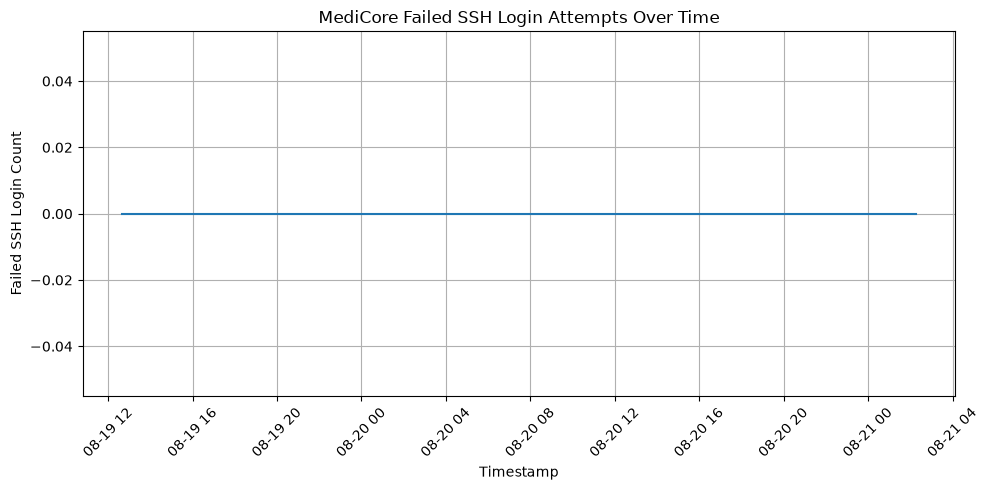

In [32]:
plt.figure(figsize=(10,5))

plt.plot(ssh_clean["timestamp"], ssh_clean["failed_logins"])

plt.title("MediCore Failed SSH Login Attempts Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Failed SSH Login Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("Failed_SSH_Login_Attempts_Over_Time.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
ssh_hourly = (ssh_clean.set_index("timestamp")["failed_logins"].resample("1h").sum())
ssh_hourly.head(10)

timestamp
2026-08-19 12:00:00    0.0
2026-08-19 13:00:00    0.0
2026-08-19 14:00:00    0.0
2026-08-19 15:00:00    0.0
2026-08-19 16:00:00    0.0
2026-08-19 17:00:00    0.0
2026-08-19 18:00:00    0.0
2026-08-19 19:00:00    0.0
2026-08-19 20:00:00    0.0
2026-08-19 21:00:00    0.0
Freq: h, Name: failed_logins, dtype: float64

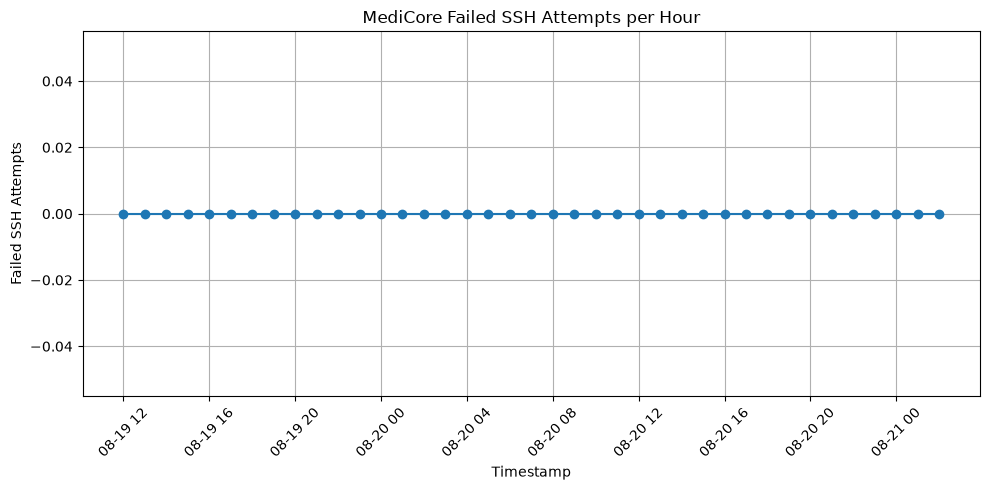

In [31]:
plt.figure(figsize=(10,5))

plt.plot(
    ssh_hourly.index, 
    ssh_hourly.values, 
    marker="o")

plt.title("MediCore Failed SSH Attempts per Hour")
plt.xlabel("Timestamp")
plt.ylabel("Failed SSH Attempts")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("Failed_SSH_Attempts_Per_Hour.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
from pathlib import Path

list(Path(".").glob("*.csv"))


[PosixPath('FailedSSHLoginCount-2026_08_19_12_40_00-2026_08_21_02_15_00-UTC.csv'),
 PosixPath('RDS-FreeStorageSpace-2026_08_19_13_48_00-2026_08_26_13_46_00-UTC.csv'),
 PosixPath('RDS-DatabaseConnections-2026_08_19_12_52_00-2026_08_26_12_50_00-UTC.csv'),
 PosixPath('CloudWatch-CPUUtilization-2026_08_19_12_45_00-2026_08_26_11_45_00-UTC.csv'),
 PosixPath('RDS-CPUUtilization-2026_08_19_12_39_00-2026_08_26_12_37_00-UTC.csv')]

In [18]:
from pathlib import Path

rds_file = list(Path(".").glob("*RDS-CPUUtilization*.csv"))[0]
rds_raw = pd.read_csv(rds_file)

rds_raw.head(10)

,Id,m1
0,StatusCode,Complete
1,Messages,NaN
2,Full label,eu-west-2:AWS/RDS DBInstanceIdentifier:medicor...
3,Label,CPUUtilization
4,2026/08/19 12:39:00,3.6880400939076576
5,2026/08/19 12:40:00,3.450057500958349
6,2026/08/19 12:41:00,3.9622956289622957
7,2026/08/19 12:42:00,3.299890003666545
8,2026/08/19 12:43:00,3.283388056467608
9,2026/08/19 12:44:00,3.729727929667988


In [21]:
rds_clean = rds_raw.iloc[4:].copy()

rds_clean.columns = ["timestamp", "cpu_percent"]

rds_clean["timestamp"] = pd.to_datetime(rds_clean["timestamp"])
rds_clean["cpu_percent"] = pd.to_numeric(rds_clean["cpu_percent"], errors="coerce")

print(rds_clean.head())
print(rds_clean["cpu_percent"].describe())

            timestamp  cpu_percent
4 2026-08-19 12:39:00     3.688040
5 2026-08-19 12:40:00     3.450058
6 2026-08-19 12:41:00     3.962296
7 2026-08-19 12:42:00     3.299890
8 2026-08-19 12:43:00     3.283388
count    10077.000000
mean         3.826748
std          0.841688
min          2.557737
25%          3.330059
50%          3.808397
75%          4.185984
max         52.616667
Name: cpu_percent, dtype: float64


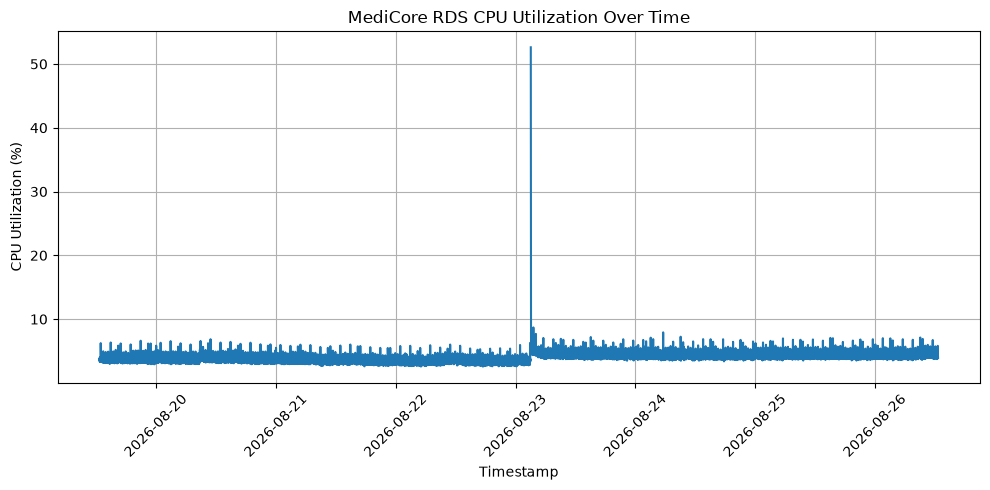

In [26]:
plt.figure(figsize=(10,5))

plt.plot(rds_clean["timestamp"], rds_clean["cpu_percent"])

plt.title("MediCore RDS CPU Utilization Over Time")
plt.xlabel("Timestamp")
plt.ylabel("CPU Utilization (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig("RDS_CPU_Utilization.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
from pathlib import Path
list(Path(".").glob("*.png"))

[PosixPath('RDS_CPU_Utilization.png')]

## A6 – Data Analysis and Security Interpretation

### Security Analysis

The CloudWatch data was analysed to identify operational and security-related
patterns within the deployed MediCore environment. The EC2 and RDS CPU
visualisations show the utilisation of the deployed resources over time. RDS
CPU utilisation remained relatively low for most of the monitoring period,
although a significant peak of approximately 52.6% was observed. This
demonstrates how time-series monitoring can identify abnormal resource
activity that may require further investigation.

The failed SSH login data was also analysed over time and aggregated by hour
to identify potential attack windows. No failed SSH attempts were recorded
during the captured monitoring period. Although no brute-force activity was
observed in this dataset, failed SSH authentication remains a relevant threat
for an Internet-accessible infrastructure. The absence of recorded attempts
does not remove the risk; instead, it provides a baseline against which future
activity can be compared.

This analysis supports Risk R01 in the MediCore security risk register:
unauthorised SSH access and brute-force login attempts. Restricting SSH access
through the bastion architecture and monitoring failed authentication attempts
reduces the likelihood of unauthorised access and provides evidence for
security monitoring and incident detection.